Name:- Baibhaw Kumar <br>
Roll No:- 2310110712 <br>
Assignment - 3



### Objective

The objective of this assignment is to implement and evaluate Support Vector Machine (SVM) classifiers with different kernels for the MNIST digit classification dataset. The performance of Linear, Gaussian (RBF), and Polynomial kernels is compared by measuring their accuracy on the test dataset.  

Q2 nonlinear regression methods such as K-Nearest Neighbors (KNN) and Random Forest are applied to estimate an unknown function generated from noisy data, and their predictions are analyzed and visualized.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
%pip install scikit-learn

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC


### Data Loading

In this step, the MNIST dataset is loaded using the pandas library. The dataset contains images of handwritten digits where each row represents one image sample.

The first column corresponds to the digit label (0–9), which is the target variable, and the remaining columns represent the pixel intensity values of the image.

The dataset is separated into:
- Feature matrix (X): containing the pixel values.
- Target vector (y): containing the digit labels.

Since Support Vector Machines perform better when the features are on a similar scale, the pixel values are normalized using StandardScaler.

Finally, the dataset is split into training and testing sets using `train_test_split`, where:
- 80% of the data is used for training the model.
- 20% of the data is used for evaluating the model.

In [7]:
data = pd.read_csv("/content/MNIST.csv")
print("data_shape:",data.shape)
data.head()

data_shape: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
x = data.iloc[:, 1:].values #pixel_value
y = data.iloc[:, 0].values   # labels

print("Feature shape:", x.shape)
print("Label shape:", y.shape)

Feature shape: (42000, 784)
Label shape: (42000,)


In [9]:
# Normalize features
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [10]:
# Train test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

a Linear SVM with different C

C controls regularization strength.

small C large margin  more regularization

large C smaller margin  fits data more

In [12]:
c_value = [0.1,1,10]
for C in c_value:
    svm = SVC(kernel = "linear", C=C)
    svm.fit(x_train , y_train)
    y_predict = svm.predict(x_test)
    acc = accuracy_score(y_test, y_predict)

    print("C =",C," Accuracy =",acc)

C = 0.1  Accuracy = 0.9298809523809524
C = 1  Accuracy = 0.9205952380952381
C = 10  Accuracy = 0.9133333333333333


### SVM with Gaussian (RBF) Kernel

In this step, a Support Vector Machine classifier is trained using the **Gaussian Radial Basis Function (RBF) kernel**.  
Unlike the linear kernel, the RBF kernel can capture **nonlinear decision boundaries**, making it suitable for complex datasets such as handwritten digit images.

The RBF kernel function is defined as:

K(x, x′) = exp(−||x − x′||² / (2σ²))

where σ² controls the spread of the Gaussian function.

In scikit-learn, the parameter **gamma (γ)** is used instead of σ², and the relationship between them is:

γ = 1 / (2σ²)

Two different parameter settings are evaluated:

**Case 1**
- C = 0.1  
- σ² = 1  
- γ = 1 / (2 × 1) = 0.5  

**Case 2**
- C = 1  
- σ² = 0.1  
- γ = 1 / (2 × 0.1) = 5  

For each configuration, the SVM model is trained on the training dataset and its performance is evaluated on the test dataset using the **accuracy score**.

In [13]:
val = [(0.1,1),(1,0.1)]

for C, sigma2 in val:
    gamma = 1/(2*sigma2)
    svm = SVC(kernel='rbf', C=C, gamma=gamma)
    svm.fit(x_train, y_train)
    y_pred = svm.predict(x_test)
    acc = accuracy_score(y_test, y_pred)

    print("C =",C," sigma^2 =",sigma2," Accuracy =",acc)

C = 0.1  sigma^2 = 1  Accuracy = 0.10821428571428572
C = 1  sigma^2 = 0.1  Accuracy = 0.10821428571428572


### SVM with Polynomial Kernel

In this step, a Support Vector Machine classifier is trained using the **Polynomial kernel**.  
The polynomial kernel allows the model to learn **nonlinear decision boundaries** by mapping the input features into a higher-dimensional feature space.

The polynomial kernel function is defined as:

K(x, x′) = (x · x′ + 1)^d

where **d** represents the degree of the polynomial.

To analyze the effect of model complexity, two different polynomial degrees are tested:

- d = 2
- d = 4

For each degree, the SVM classifier is trained using the training dataset.  
After training, predictions are made on the test dataset and the **accuracy score** is calculated to evaluate the performance of the model.

Increasing the degree of the polynomial allows the classifier to model more complex relationships, but very high degrees may lead to overfitting.

In [15]:
degrees = [2,4]
for d in degrees:
    svm = SVC(kernel='poly', degree=d)
    svm.fit(x_train, y_train)
    y_pred = svm.predict(x_test)
    acc = accuracy_score(y_test, y_pred)

    print("Degree =",d," Accuracy =",acc)

Degree = 2  Accuracy = 0.9669047619047619
Degree = 4  Accuracy = 0.8598809523809524


## Final Comparison of Models

In this assignment, multiple machine learning models were implemented and evaluated for the MNIST digit classification dataset. The models tested include Linear SVM, SVM with Gaussian (RBF) kernel, SVM with Polynomial kernel, and Random Forest classifier.

The performance of each model was measured using the **accuracy score on the test dataset**.

### Model Performance

| Model | Parameters | Accuracy |
|------|-----------|---------|
| Linear SVM | C = 0.1 | 0.9299 |
| Linear SVM | C = 1 | 0.9206 |
| Linear SVM | C = 10 | 0.9133 |
| RBF SVM | C = 0.1, σ² = 1 | 0.1082 |
| RBF SVM | C = 1, σ² = 0.1 | 0.1082 |
| Polynomial SVM | Degree = 2 | **0.9669** |
| Polynomial SVM | Degree = 4 | 0.8599 |
| Random Forest | Default parameters | 0.9611 |

### Observations

- The **Polynomial SVM with degree = 2 achieved the highest accuracy (96.69%)**, indicating that a moderate nonlinear decision boundary works well for this dataset.
- **Random Forest** also performed very well with an accuracy of **96.11%**, showing that ensemble methods are effective for classification tasks.
- **Linear SVM** produced reasonably good results (around 92–93%), but it may not fully capture the nonlinear patterns present in the data.
- **Polynomial SVM with degree = 4** performed worse than degree 2, which may indicate **overfitting due to higher model complexity**.
- The **RBF kernel performed poorly with the chosen parameter values**, giving accuracy close to random guessing. This suggests that the hyperparameters were not optimal and require further tuning.

### Conclusion

Among all the tested models, **Polynomial SVM with degree = 2 provided the best performance** for the MNIST classification task in this experiment. Random Forest also achieved competitive accuracy and can be considered a strong alternative.

Q2

In [16]:
np.random.seed(42) #why 42? coz its answer to life
N = 30 #number of sample
x = np.random.uniform(0,3,N) #uniformly distributed
noise = np.random.normal(0,0.5,N) #normal distribution noise
y = 2*np.sin(x) + noise
X = x.reshape(-1,1) #because of scikit-learn format

In [17]:
x_test = np.array(
[0,0.35,0.70,1.05,1.40,1.75,2.10,2.45,2.80,3.14]
).reshape(-1,1)

### Test Points for Function Estimation

To evaluate the regression models, predictions are required at specific input points.

The following values are chosen within the range of the dataset:

0, 0.35, 0.70, 1.05, 1.40, 1.75, 2.10, 2.45, 2.80, 3.14

These points are used to estimate the unknown regression function \(m(x)\) using the trained models.

### K-Nearest Neighbors (KNN) Regression

The **K-Nearest Neighbors regression** method estimates the value of the function at a given point by averaging the values of the nearest neighboring data points.

The model identifies the **k closest samples** in the training dataset and computes the predicted value based on their outputs.

This method is simple and effective for capturing local patterns in the data.

In [18]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X,y)
y_knn = knn.predict(x_test)

### Random Forest Regression

Random Forest regression is an **ensemble learning method** that uses multiple decision trees to make predictions.

Each tree is trained on a randomly selected subset of the data, and the final prediction is obtained by averaging the outputs of all trees**.

This approach improves prediction accuracy and reduces overfitting compared to a single decision tree.

In [19]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200)
rf.fit(X,y)
y_rf = rf.predict(x_test)

In [20]:
print("x values:",x_test.flatten())
print("KNN estimates:",y_knn)
print("RF estimates:",y_rf)

x values: [0.   0.35 0.7  1.05 1.4  1.75 2.1  2.45 2.8  3.14]
KNN estimates: [0.89618324 1.10358942 1.15780489 1.3069299  1.73781667 2.03671095
 1.53849442 0.93536835 0.50057148 0.50057148]
RF estimates: [ 0.38326013  1.36634699  1.15793569  1.05092196  1.90698937  2.31075236
  1.19066265  0.69187942  0.46717459 -0.00603748]


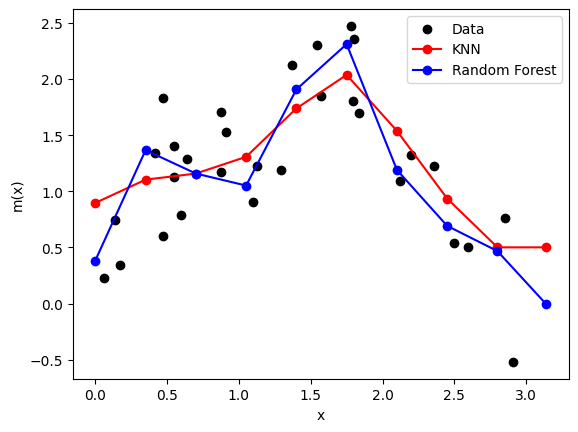

In [21]:
plt.scatter(x,y,color='black',label='Data')
plt.plot(x_test,y_knn,'r-o',label='KNN')
plt.plot(x_test,y_rf,'b-o',label='Random Forest')
plt.legend()
plt.xlabel("x")
plt.ylabel("m(x)")

plt.show()